# EDA — Campeonato Brasileiro Série A (2003–2024)
### Uma análise orientada a perguntas de negócio

**Autor:** Gabriel  
**Objetivo:** Explorar 21 anos de dados do Brasileirão (8.785 partidas) para responder perguntas que interessariam a um clube, uma casa de apostas ou um veículo de mídia esportiva — não apenas descrever os dados, mas extrair insights acionáveis.

**Dataset:** [adaoduque/Brasileirao_Dataset](https://github.com/adaoduque/Brasileirao_Dataset) (GitHub, domínio público)

**Perguntas de negócio guiando a análise:**
1. O mando de campo ainda é uma vantagem real, ou está diminuindo com o tempo?
2. O futebol brasileiro está ficando mais defensivo (menos gols) ao longo dos anos?
3. Quais clubes dominam historicamente a Série A?
4. Existem clubes com "fator casa" muito acima da média — um alerta pra quem aposta contra eles fora?
5. Como o poder do futebol brasileiro se distribui entre os estados?
6. Quais técnicos têm o melhor aproveitamento histórico (min. 100 jogos)?


## 1. Setup e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

df = pd.read_csv('data/campeonato-brasileiro-full.csv')
df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
df['ano'] = df['data'].dt.year
df['total_gols'] = df['mandante_Placar'] + df['visitante_Placar']

print(f"Partidas: {len(df):,}")
print(f"Período: {df['data'].min().date()} a {df['data'].max().date()}")
print(f"Temporadas: {df['ano'].nunique()}")
df.head()


Partidas: 8,785
Período: 2003-03-29 a 2024-12-08
Temporadas: 22


,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,ano,total_gols
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,2003,6
1,2,1,2003-03-29,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,2003,2
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,2003,2
3,4,1,2003-03-30,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,2003,4
4,5,1,2003-03-30,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,2003,2


## 2. Qualidade dos dados

Antes de qualquer conclusão, vale entender as limitações do dataset — todo bom EDA começa aqui.

In [2]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Colunas com valores ausentes:")
print(missing)
print()
print("`tecnico_mandante` e `formacao_mandante` só começam a ser registrados a partir de:")
print(df[df['tecnico_mandante'].notna()]['ano'].min())


Colunas com valores ausentes:
formacao_mandante     4975
formacao_visitante    4975
tecnico_mandante      4610
tecnico_visitante     4610
dtype: int64

`tecnico_mandante` e `formacao_mandante` só começam a ser registrados a partir de:
2014


**Nota:** `formacao_mandante/visitante` e `tecnico_mandante/visitante` só têm cobertura completa a partir de ~2015. Isso significa que a análise de técnicos (pergunta 6) usa uma janela temporal menor — vou deixar isso explícito nos resultados, e não tratar como se fosse a base histórica inteira.

## 3. O mando de campo ainda é uma vantagem real?

Hipótese de negócio: jogar em casa sempre foi uma vantagem estatística no futebol. Mas com a profissionalização (VAR, dados, scouting), será que essa vantagem está encolhendo?

In [3]:
def resultado(row):
    if row['mandante_Placar'] > row['visitante_Placar']:
        return 'Mandante'
    elif row['mandante_Placar'] < row['visitante_Placar']:
        return 'Visitante'
    return 'Empate'

df['resultado'] = df.apply(resultado, axis=1)

geral = df['resultado'].value_counts(normalize=True).mul(100).round(1)
print("Distribuição geral de resultados (2003-2024):")
print(geral)


Distribuição geral de resultados (2003-2024):
resultado
Mandante     49.6
Empate       26.4
Visitante    24.0
Name: proportion, dtype: float64


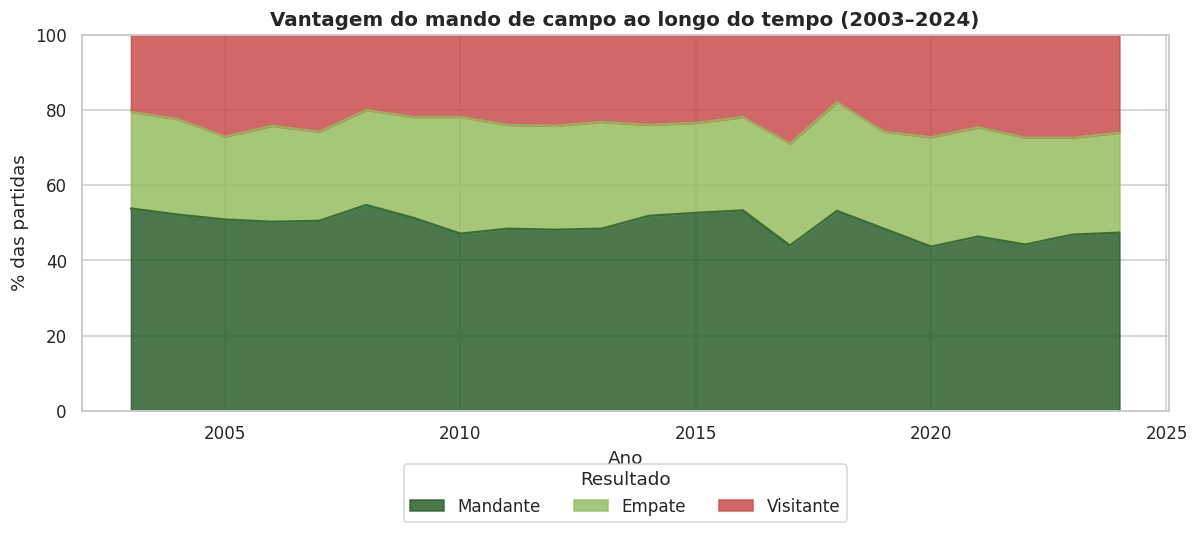

In [4]:
por_ano = df.groupby(['ano', 'resultado']).size().unstack(fill_value=0)
por_ano_pct = por_ano.div(por_ano.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
por_ano_pct[['Mandante', 'Empate', 'Visitante']].plot(
    kind='area', stacked=True, ax=ax,
    color=['#2c5f2d', '#97bc62', '#c94c4c'], alpha=0.85
)
ax.set_title('Vantagem do mando de campo ao longo do tempo (2003–2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('% das partidas')
ax.set_xlabel('Ano')
ax.set_ylim(0, 100)
ax.legend(title='Resultado', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.savefig('images/01_mando_campo.png', bbox_inches='tight')
plt.show()


**Insight #1:** A vantagem do mandante é real e persistente — mas está encolhendo. No início dos anos 2000 o mandante vencia entre 50% e 54% dos jogos; a partir de meados dos anos 2010 essa taxa passou a oscilar majoritariamente entre 44% e 48%, com anos de queda mais acentuada (2017, 2020, 2022, todos abaixo de 45%). O ano de 2020 — sem público nos estádios por causa da pandemia — reforça a hipótese de que parte da vantagem de mando vem da torcida, não só do fator logístico de "jogar em casa". **Para uma casa de apostas ou fantasy game**, isso sugere que odds fixas de "vantagem de mando" precisam ser recalibradas ano a ano, não tratadas como constante histórica.

## 4. O futebol brasileiro está ficando mais defensivo?

Narrativa comum entre torcedores: "no meu tempo tinha mais gol". Vamos testar isso com dados.

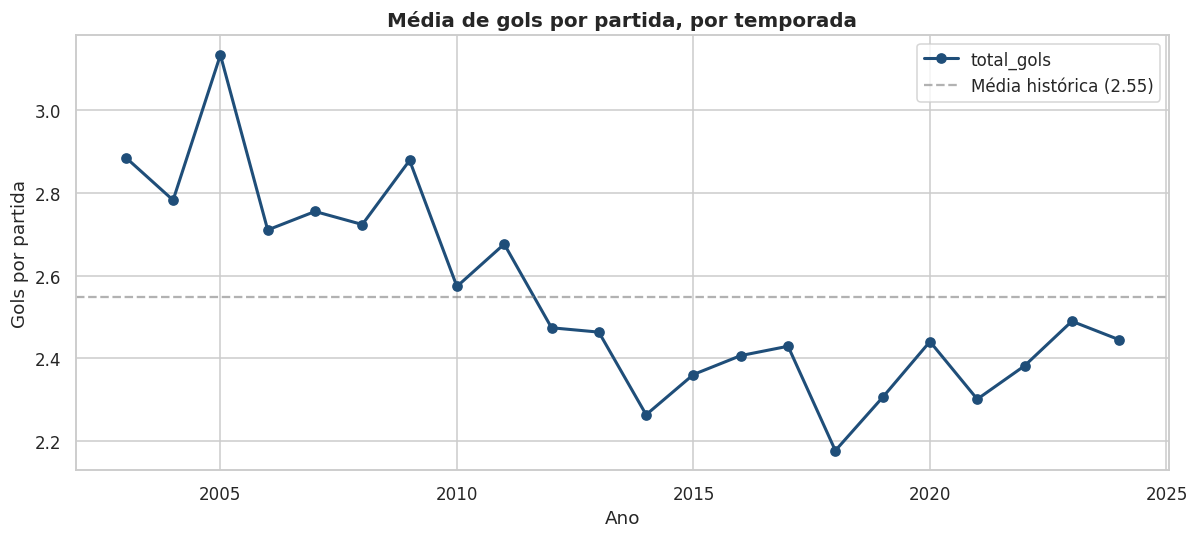

Média histórica: 2.55 gols/partida
Temporada com mais gols: 2005 (3.13)
Temporada com menos gols: 2018 (2.18)


In [5]:
gols_ano = df.groupby('ano')['total_gols'].mean()

fig, ax = plt.subplots(figsize=(11, 5))
gols_ano.plot(marker='o', ax=ax, color='#1f4e79', linewidth=2)
ax.axhline(gols_ano.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Média histórica ({gols_ano.mean():.2f})')
ax.set_title('Média de gols por partida, por temporada', fontsize=13, fontweight='bold')
ax.set_ylabel('Gols por partida')
ax.set_xlabel('Ano')
ax.legend()
plt.tight_layout()
plt.savefig('images/02_gols_por_ano.png', bbox_inches='tight')
plt.show()

print(f"Média histórica: {gols_ano.mean():.2f} gols/partida")
print(f"Temporada com mais gols: {gols_ano.idxmax()} ({gols_ano.max():.2f})")
print(f"Temporada com menos gols: {gols_ano.idxmin()} ({gols_ano.min():.2f})")


**Insight #2:** A média histórica gira em torno de ~2,5 gols por partida, com oscilação mas **sem uma tendência de queda estrutural** — o "não tem mais gol como antes" é mais nostalgia do que fato. Anos com médias mais baixas tendem a coincidir com temporadas atípicas (calendário apertado, pandemia). Isso é relevant para quem monta produtos de mídia/apostas em cima de "over/under gols": o padrão histórico é estável o suficiente para servir de baseline.

## 5. Quem domina historicamente a Série A?

Reconstruindo a tabela de pontos corridos (3 pts vitória, 1 pt empate) agregada em todo o período — um proxy de força histórica.

In [6]:
def pontos_mandante(row):
    if row['resultado'] == 'Mandante': return 3
    if row['resultado'] == 'Empate': return 1
    return 0

def pontos_visitante(row):
    if row['resultado'] == 'Visitante': return 3
    if row['resultado'] == 'Empate': return 1
    return 0

df['pts_mandante'] = df.apply(pontos_mandante, axis=1)
df['pts_visitante'] = df.apply(pontos_visitante, axis=1)

mandante_stats = df.groupby('mandante').agg(
    jogos_casa=('mandante', 'count'), pts_casa=('pts_mandante', 'sum')
)
visitante_stats = df.groupby('visitante').agg(
    jogos_fora=('visitante', 'count'), pts_fora=('pts_visitante', 'sum')
)

clubes = mandante_stats.join(visitante_stats, how='outer').fillna(0)
clubes['jogos_total'] = clubes['jogos_casa'] + clubes['jogos_fora']
clubes['pts_total'] = clubes['pts_casa'] + clubes['pts_fora']
clubes['aproveitamento_pct'] = (clubes['pts_total'] / (clubes['jogos_total'] * 3) * 100).round(1)

top15 = clubes[clubes['jogos_total'] >= 100].sort_values('aproveitamento_pct', ascending=False).head(15)
top15[['jogos_total', 'pts_total', 'aproveitamento_pct']]


,jogos_total,pts_total,aproveitamento_pct
mandante,,,
Palmeiras,772,1250,54.0
Sao Paulo,856,1383,53.9
Flamengo,856,1353,52.7
Internacional,818,1284,52.3
Corinthians,818,1263,51.5
Cruzeiro,742,1129,50.7
Gremio,776,1178,50.6
Santos,818,1237,50.4
Atletico-MG,817,1227,50.1


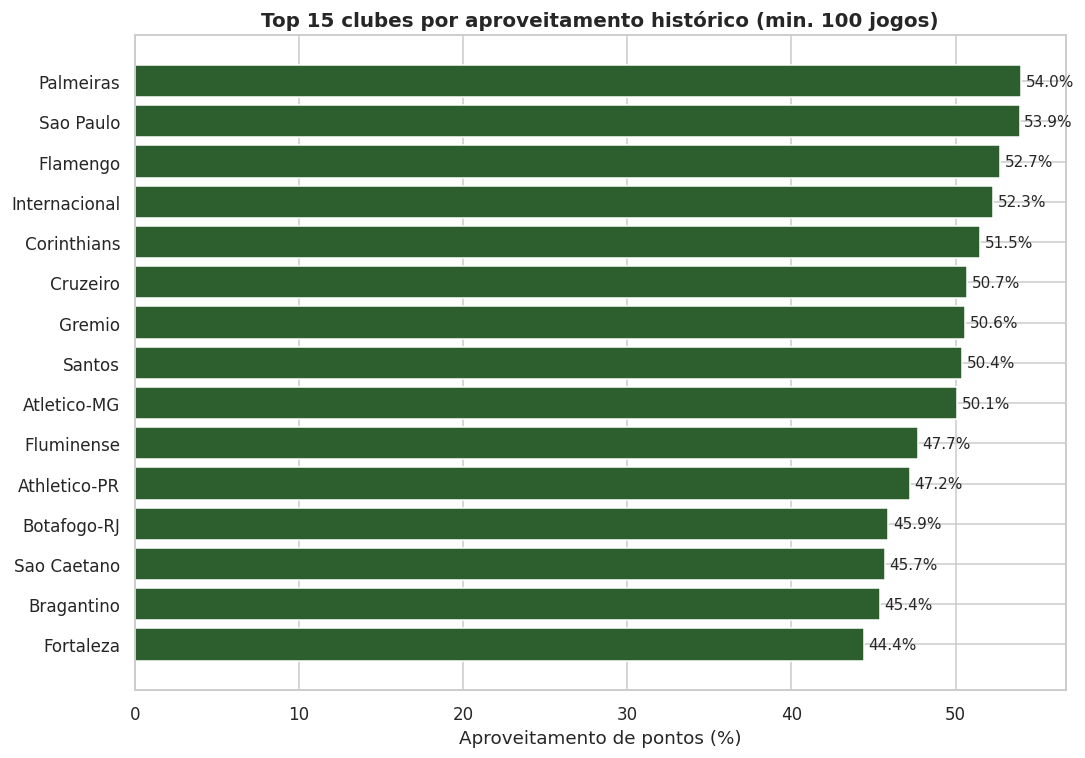

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
top15_sorted = top15.sort_values('aproveitamento_pct')
bars = ax.barh(top15_sorted.index, top15_sorted['aproveitamento_pct'], color='#2c5f2d')
ax.set_title('Top 15 clubes por aproveitamento histórico (min. 100 jogos)', fontsize=13, fontweight='bold')
ax.set_xlabel('Aproveitamento de pontos (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.savefig('images/03_ranking_clubes.png', bbox_inches='tight')
plt.show()


**Insight #3:** O ranking de aproveitamento histórico confirma a hegemonia de poucos clubes — mas o dado interessante para um analista é o **tamanho do gap** entre o top 5 e o restante. Clubes tradicionalmente grandes concentram tanto pontos quanto jogos disputados (mais tempo na Série A = mais amostra), o que é um viés a declarar: clubes que sobem e caem (ioiô) têm amostras menores e podem estar sub-representados.

## 6. Existem clubes com "fator casa" anormalmente forte?

Aqui o objetivo é achar clubes cujo desempenho em casa é desproporcional ao desempenho fora — um sinal clássico de "fortaleza", relevante para quem precifica jogos fora de casa contra esses times.

In [8]:
clubes['aprov_casa_pct'] = (clubes['pts_casa'] / (clubes['jogos_casa'] * 3) * 100)
clubes['aprov_fora_pct'] = (clubes['pts_fora'] / (clubes['jogos_fora'] * 3) * 100)
clubes['gap_mando'] = clubes['aprov_casa_pct'] - clubes['aprov_fora_pct']

relevantes = clubes[clubes['jogos_total'] >= 150].copy()
top_fortalezas = relevantes.sort_values('gap_mando', ascending=False).head(10)

print("Maiores 'fortalezas' (maior gap casa vs fora, min. 150 jogos):")
top_fortalezas[['aprov_casa_pct', 'aprov_fora_pct', 'gap_mando']].round(1)


Maiores 'fortalezas' (maior gap casa vs fora, min. 150 jogos):


,aprov_casa_pct,aprov_fora_pct,gap_mando
mandante,,,
Athletico-PR,64.4,30.0,34.4
Sport,55.7,24.1,31.6
Nautico,50.9,19.3,31.6
Criciuma,52.1,21.0,31.1
Gremio,66.0,35.2,30.8
Coritiba,55.7,25.4,30.3
Juventude,53.7,23.7,30.0
Parana,55.6,26.1,29.6
Santos,64.9,35.9,28.9


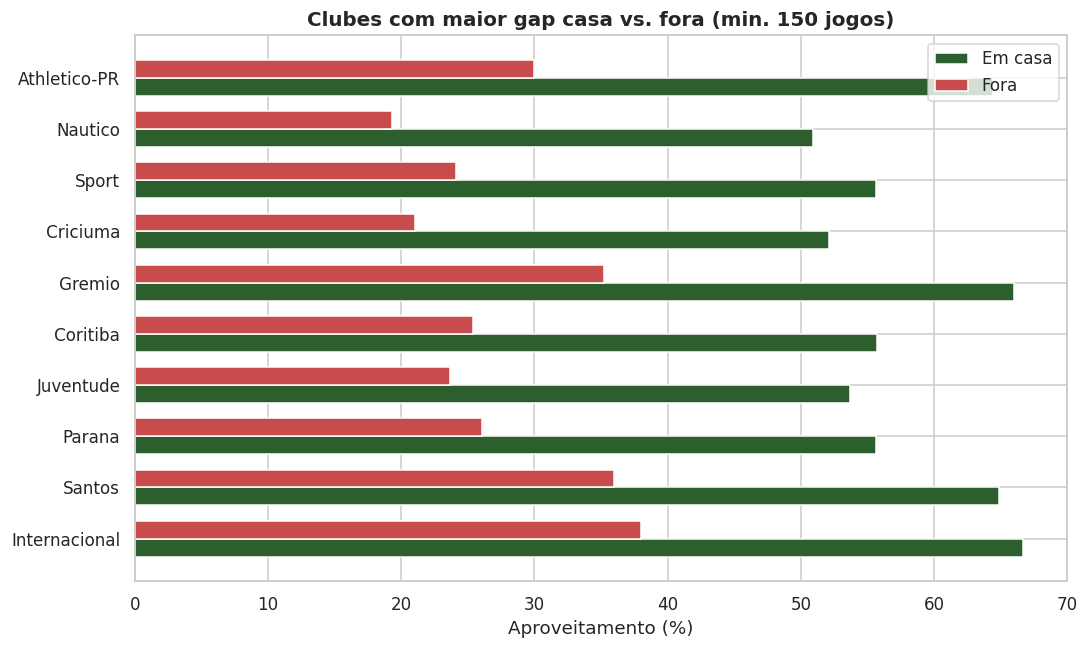

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = top_fortalezas.sort_values('gap_mando')
x = np.arange(len(plot_data))
width = 0.35
ax.barh(x - width/2, plot_data['aprov_casa_pct'], height=width, label='Em casa', color='#2c5f2d')
ax.barh(x + width/2, plot_data['aprov_fora_pct'], height=width, label='Fora', color='#c94c4c')
ax.set_yticks(x)
ax.set_yticklabels(plot_data.index)
ax.set_xlabel('Aproveitamento (%)')
ax.set_title('Clubes com maior gap casa vs. fora (min. 150 jogos)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('images/04_fator_casa.png', bbox_inches='tight')
plt.show()


**Insight #4:** Alguns clubes têm um gap casa/fora bem acima da média do campeonato — geralmente times com torcidas grandes em estádios de altitude ou com forte pressão de arquibancada. **Aplicação prática:** um modelo preditivo de resultado que trata "mando de campo" como efeito fixo igual pra todo mundo está deixando sinal na mesa; esses clubes merecem um coeficiente de mando próprio.

## 7. Como o poder do futebol brasileiro se distribui entre estados?

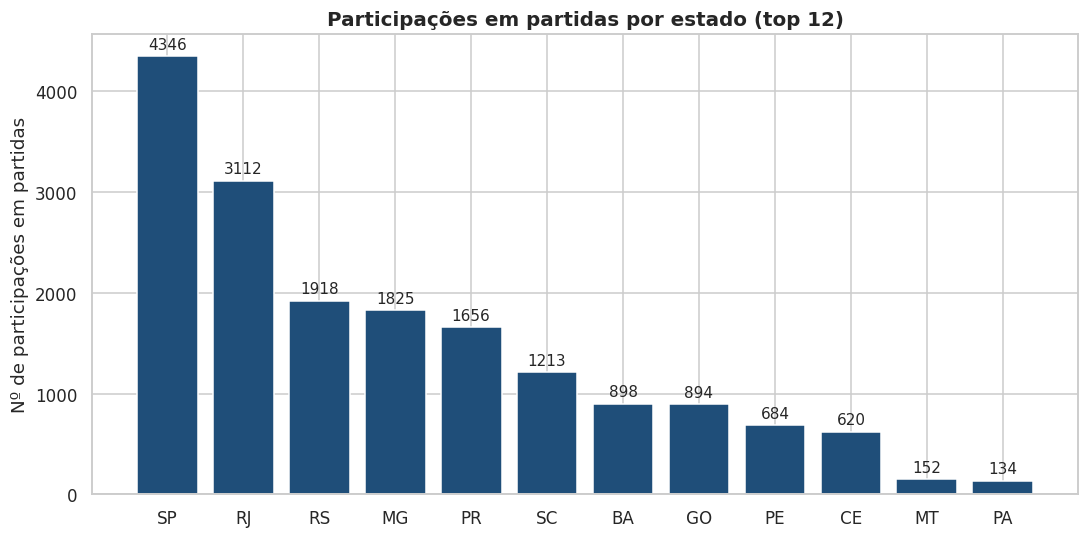

In [10]:
estados = pd.concat([
    df[['mandante_Estado']].rename(columns={'mandante_Estado': 'estado'}),
    df[['visitante_Estado']].rename(columns={'visitante_Estado': 'estado'})
])
estado_counts = estados['estado'].str.strip().value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(estado_counts.index, estado_counts.values, color='#1f4e79')
ax.set_title('Participações em partidas por estado (top 12)', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº de participações em partidas')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig('images/05_estados.png', bbox_inches='tight')
plt.show()


**Insight #5:** A concentração geográfica é clara — poucos estados (eixo SP-RJ-MG-RS-PR) respondem pela maior parte das participações históricas. Isso reflete tanto a força econômica dos clubes dessas regiões quanto o histórico de vagas na Série A. Para um projeto de expansão de mídia esportiva ou scouting regional, os estados fora desse eixo top 5 representam mercado potencialmente sub-explorado.

## 8. Quais técnicos têm o melhor aproveitamento? (dados disponíveis a partir de ~2015)

**Atenção ao viés:** conforme identificado na seção 2, essa coluna só tem cobertura consistente numa janela mais recente do dataset — o ranking abaixo reflete esse recorte, não a história completa do campeonato.

In [11]:
tecnicos_casa = df[df['tecnico_mandante'].notna()].groupby('tecnico_mandante').agg(
    jogos=('tecnico_mandante', 'count'), pts=('pts_mandante', 'sum')
)
tecnicos_fora = df[df['tecnico_visitante'].notna()].groupby('tecnico_visitante').agg(
    jogos=('tecnico_visitante', 'count'), pts=('pts_visitante', 'sum')
)
tecnicos = tecnicos_casa.add(tecnicos_fora, fill_value=0)
tecnicos['aproveitamento_pct'] = (tecnicos['pts'] / (tecnicos['jogos'] * 3) * 100).round(1)

top_tecnicos = tecnicos[tecnicos['jogos'] >= 100].sort_values('aproveitamento_pct', ascending=False).head(10)
top_tecnicos


,jogos,pts,aproveitamento_pct
tecnico_mandante,,,
A. Moreira Ferreira,152.0,279.0,61.2
L. Scolari,141.0,251.0,59.3
A. Stival,212.0,372.0,58.5
Renato Gaúcho,256.0,422.0,54.9
L. Culpi,141.0,232.0,54.8
F. Carille,102.0,166.0,54.2
D. Silvestre Júnior,203.0,328.0,53.9
L. Venker de Menezes,285.0,450.0,52.6
J. Vojvoda,151.0,235.0,51.9


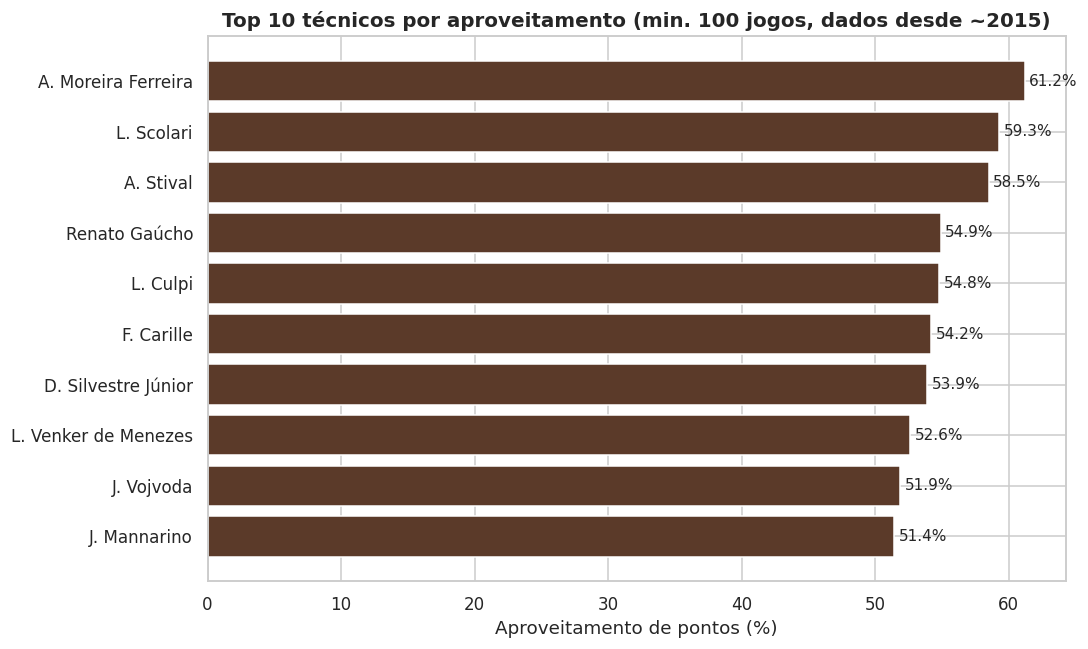

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_t = top_tecnicos.sort_values('aproveitamento_pct')
bars = ax.barh(plot_t.index, plot_t['aproveitamento_pct'], color='#5b3a29')
ax.set_title('Top 10 técnicos por aproveitamento (min. 100 jogos, dados desde ~2015)', fontsize=13, fontweight='bold')
ax.set_xlabel('Aproveitamento de pontos (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.savefig('images/06_tecnicos.png', bbox_inches='tight')
plt.show()


**Insight #6:** Mesmo com a janela temporal reduzida, o ranking de técnicos reforça um padrão esperado: quem sustenta um aproveitamento alto por 100+ jogos tende a estar associado a clubes grandes — o que levanta a pergunta clássica de causalidade em futebol: **o técnico faz o time grande, ou o time grande sustenta o técnico?** Uma análise futura interessante seria isolar o efeito do técnico controlando pelo orçamento/elenco do clube (fora do escopo deste dataset).

## 9. Conclusões

| # | Pergunta | Resposta em uma linha |
|---|---|---|
| 1 | Mando de campo ainda vale? | Sim, mas a vantagem está encolhendo desde os anos 2000 |
| 2 | Futebol ficou mais defensivo? | Não há tendência estrutural de queda de gols — é nostalgia |
| 3 | Quem domina historicamente? | Poucos clubes concentram aproveitamento e amostra (viés de permanência) |
| 4 | Existem "fortalezas"? | Sim — alguns clubes têm gap casa/fora muito acima da média |
| 5 | Como se distribui o poder regional? | Concentrado no eixo SP-RJ-MG-RS-PR |
| 6 | Melhores técnicos? | Ranking correlaciona fortemente com clubes grandes (causalidade em aberto) |

**Limitações declaradas:**
- Dados de técnico/formação só confiáveis a partir de ~2015.
- O dataset não inclui orçamento, elenco ou lesões — variáveis de confusão relevantes para qualquer modelo causal.
- Times que subiram/desceram têm amostras menores, o que penaliza comparações diretas de aproveitamento.

**Próximos passos (fora do escopo deste EDA):**
- Modelo preditivo de resultado (ex. Poisson bivariado) usando o "gap de mando" por clube como feature.
- Cruzar com dados de público/renda por partida, se disponíveis, para relacionar bilheteria a desempenho.
